this is the rough copy

Pipeline notes: PIXC height data + river centreline + river boundary/AOI
                         
choose a local cross-section
                         
identify centre + two river-edge anchor points
                         
draw equal configurable-radius neighbourhoods
                         
calculate local mean/median height at each anchor
                         
Δh = edge height − centre height
                         
repeat for several radii and save results

In [ ]:
#installations and imports

!pip install -q geopandas pyogrio shapely #this is in case need aoi!!

from dataclasses import dataclass #new one to help with the configurables
from pathlib import Path #this is to clean up the directories cus theyve been an issueeee
import logging #new one to make a log instead of printing a million things
import shutil

import subprocess
import geopandas as gpd #these are just classic
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from shapely.geometry import Point, LineString, MultiLineString
from shapely.ops import unary_union
from shapely.geometry.base import BaseGeometry

In [ ]:
#config!!!!


@dataclass(frozen=True) #once config made cant change so each script run is set!
class HeightAnalysisConfig:

    #files in
    pixc_file: Path
    centreline_file: Path
    river_boundary_file: Path
    ground_track_file: Path

    #where they end up
    output_directory: Path

    #coords!!!
    projected_crs: str = "EPSG:32632"

    #pixc col
    height_column: str = "height"

    #config var
    angle_tolerance_deg: float = 20.0
    minimum_perpendicular_run: int = 3

    local_search_radius_m: float = 500.0 # we dont want to search whole pixc file, just the 500m reach


   #same j making a box so our river is somewhere in thissss to find the edges later.
    cross_section_half_length_m: float = 500.0

    #seeing if lies in the polygon, can add tolerance in case of small mismatches!!!
    boundary_coverage_tolerance_m: float = 0.0

    #stopping v small diff in float vals from combinibg them
    anchor_point_dedupe_tolerance_m: float = 0.01

    #how zoomed figs are
    cross_section_plot_zoom_m: float = 200.0

   #delta H local area!!!! and were saying we want at least 20 points in that radius so if not we can increase?
    sample_radius_m: float = 20.0
    minimum_sample_points: int = 10

    #how does delta H change w diff radii?
    sensitivity_radii_m: tuple[float, ...] = (5.0, 10.0, 15.0, 20.0, 30.0)


    #SAVEEEEE, was j getting annoying saving everything when test running
    save_figures: bool = True

#we're working on j our config vals !!!! MASSIVE clean upppp
config = HeightAnalysisConfig(
    pixc_file=Path(
        "/content/Orco/Orco_processed/"
        "PIXC_029_234R_20250408.geojson"
    ),
    centreline_file=Path(
        "/content/Orco/Orco_CL_25832.kml"
    ),
    river_boundary_file=Path(
        "/content/Orco_shapefile_uav.shp"
    ),
    ground_track_file=Path(
        "/content/sat_paths/sat_paths/"
        "SWOT_L2_HR_PIXC_031_029_234R_"
        "20250408T044534_20250408T044545_PGD0_01.csv"
    ),
    output_directory=Path(
        "/content/orco_height_outputs"
    ),
    projected_crs="EPSG:32632",
    height_column="height",
    angle_tolerance_deg=20.0,
    minimum_perpendicular_run=3,
    local_search_radius_m=500.0,
    sample_radius_m=20.0,
    minimum_sample_points=10,
)


zip_file = Path(
    "/content/Orco_river.zip"
)

rar_file = Path(
    "/content/sat_paths.rar"
)

zip_output_directory = Path(
    "/content/Orco"
)

rar_output_directory = Path(
    "/content/sat_paths"
)

In [ ]:
#quick optional code to unzippppppppp and extract rar

def extract_zip( #previous code was ok but trying to use  funcs more
    archive_path: Path,
    output_directory: Path
) -> None:

    if not archive_path.exists():
        raise FileNotFoundError(
            f"ZIP archive does not exist:\n{archive_path}"
        )

    output_directory.mkdir(
        parents=True,
        exist_ok=True
    )

    shutil.unpack_archive(
        filename=str(archive_path),
        extract_dir=str(output_directory),
        format="zip"
    )

    print(
        f"ZIP extracted to:\n{output_directory}"
    )


extract_zip(
    zip_file,
    zip_output_directory
)

!apt-get update -qq
!apt-get install -y -qq unrar

def extract_rar(
    archive_path: Path,
    output_directory: Path
) -> None:

    if not archive_path.exists():
        raise FileNotFoundError(
            f"RAR archive does not exist:\n{archive_path}"
        )

    output_directory.mkdir(
        parents=True,
        exist_ok=True
    )

    result = subprocess.run(
        [
            "unrar",
            "x",
            "-o+",
            str(archive_path),
            str(output_directory) + "/"
        ],
        capture_output=True,
        text=True
    )

    if result.returncode != 0:
        raise RuntimeError(
            "RAR extraction failed.\n\n"
            f"STDOUT:\n{result.stdout}\n\n"
            f"STDERR:\n{result.stderr}"
        )

    print(
        f"RAR extracted to:\n{output_directory}"
    )

#j extracting by calling the func here!!
extract_rar(
    rar_file,
    rar_output_directory
)

ZIP extracted to:
/content/Orco
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
RAR extracted to:
/content/sat_paths


In [ ]:
#directoriesss

#using logs so we dont have to keep printing things indiv-  can still use print fir specific checks!!

import logging

logging.basicConfig( #j configuring the loggggg
    level=logging.INFO,
    format="%(levelname)s | %(message)s",
    force=True,
)

logger = logging.getLogger()
logger.setLevel(logging.INFO)

logger = logging.getLogger("orco_height_analysis") #puttinh it all in here

#creating output files and returning their path!!!
def prepare_output_directories(output_directory: Path) -> dict[str, Path]:

    directories = {
        "root": output_directory,
        "figures": output_directory / "figures", #separating into figures and tables
        "tables": output_directory / "tables",
    } #j a cheeky dictionary of all our stuff

    for directory in directories.values(): #going through all folders
        directory.mkdir(parents=True, exist_ok=True) #creating that folder (also adapted from luacss')
#make all missing files and pls dont crash if we already have
    return directories


output_dirs = prepare_output_directories(config.output_directory) #calling!

logger.info("Outputs will be saved to %s", output_dirs["root"]) #j saying where it will enf up!
#j saying what the path is to check is ok ! (especially for the directories we configured)

INFO | Outputs will be saved to /content/orco_height_outputs


In [ ]:
#val

#confirming is okkkkk and that even exists
def validate_file(file_path: Path, description: str) -> None:


    if not file_path.exists(): #cant find file = raise error
        raise FileNotFoundError(
            f"{description} does not exist:\n{file_path}"
        )

    if not file_path.is_file(): #folder fine, file is notttt
        raise ValueError(
            f"{description} is not a file:\n{file_path}"
        )

    logger.info("%s found: %s", description, file_path) #checking in!

#do we have the columns we need?
def require_columns(
    gdf: gpd.GeoDataFrame,
    required_columns: set[str],
    dataset_name: str,
) -> None:

    missing_columns = required_columns.difference(gdf.columns) #tells us what is missing!!!!

    if missing_columns: #raise error if there are missing cols
        raise KeyError(
            f"{dataset_name} is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    logger.info("%s contains all required columns", dataset_name) #j a check in again!


    logger.info("%s CRS: %s", dataset_name, gdf.crs) #coordds?

#calling this for all of our files!!
validate_file(config.pixc_file, "PIXC GeoJSON")
validate_file(config.centreline_file, "River centreline")
validate_file(config.river_boundary_file, "River boundary/AOI")
validate_file(config.ground_track_file, "Satellite ground-track CSV")


INFO | PIXC GeoJSON found: /content/Orco/Orco_processed/PIXC_029_234R_20250408.geojson
INFO | River centreline found: /content/Orco/Orco_CL_25832.kml
INFO | River boundary/AOI found: /content/Orco_shapefile_uav.shp
INFO | Satellite ground-track CSV found: /content/sat_paths/sat_paths/SWOT_L2_HR_PIXC_031_029_234R_20250408T044534_20250408T044545_PGD0_01.csv


In [ ]:
#loading everything

#this whole func is basically me saying, what crs?
#can we put onto just one crs?
#and then remake as new gdf

def load_and_project(
    file_path: Path, #where!
    target_crs: str, #coord
    dataset_name: str, #tells wth went wrong
    driver: str | None = None,
) -> gpd.GeoDataFrame:

    logger.info("Loading %s", dataset_name) #what func is doinggggg

    if driver is None:
        gdf = gpd.read_file(file_path) #read auto
    else:
        gdf = gpd.read_file(file_path, driver=driver)

    if gdf.empty: #file but no rows
        raise ValueError(
            f"{dataset_name} loaded successfully but contains no rows."
        )


    projected = gdf.to_crs(target_crs) #were changing to same coord system

    if not projected.crs.is_projected: #checkingggggg
        raise ValueError(
            f"{dataset_name} must use a projected CRS for "
            "metre-based distances."
        )

    logger.info("%s loaded: %d rows", dataset_name, len(projected)) #logging to see
    logger.info("%s projected to %s", dataset_name, projected.crs)

    return projected

#j doing with all our files

pixc = load_and_project(
    file_path=config.pixc_file,
    target_crs=config.projected_crs,
    dataset_name="PIXC data",
)

river_centreline = load_and_project(
    file_path=config.centreline_file,
    target_crs=config.projected_crs,
    dataset_name="River centreline",
    driver="KML",
)

river_boundary = load_and_project(
    file_path=config.river_boundary_file,
    target_crs=config.projected_crs,
    dataset_name="River boundary/AOI",
)



INFO | Loading PIXC data
INFO | PIXC data loaded: 2630 rows
INFO | PIXC data projected to EPSG:32632
INFO | Loading River centreline
INFO | River centreline loaded: 1 rows
INFO | River centreline projected to EPSG:32632
INFO | Loading River boundary/AOI
INFO | River boundary/AOI loaded: 1 rows
INFO | River boundary/AOI projected to EPSG:32632


In [ ]:
#height vals

#this is pretty optional tbh but is basically again j cleaning the data to see if the vals we have are appropriate
#trauma nfrom when i had 800000000 NaN vals so

print("PIXC shape:") #these are basic inspection i decided to keep!!!
print(pixc.shape)

print("\nPIXC columns:")
print(pixc.columns.tolist())

print("\nPIXC height summary:")
print(
    pd.to_numeric(pixc[config.height_column], errors="coerce").describe()
)

print("\nCentreline:") #j saying what we have etc
print(river_centreline)

print("\nRiver boundary:")
print(river_boundary)


def clean_height_values( #keeping good height vals!! removes Nan etc
    pixc_gdf: gpd.GeoDataFrame,
    height_column: str,
) -> gpd.GeoDataFrame:

    cleaned = pixc_gdf.copy() #making an indep set that we can keep only clean vals in

    cleaned[height_column] = pd.to_numeric( #making actual floats
        cleaned[height_column], errors="coerce"
    )

    valid_mask = ( #j checking each cond eg is it finite and have geom?
        cleaned[height_column].notna()
        & np.isfinite(cleaned[height_column])
        & cleaned.geometry.notna()
        & ~cleaned.geometry.is_empty
    )

    number_removed = len(cleaned) - valid_mask.sum() #how many points we removed through this cleaning step

    cleaned = cleaned.loc[valid_mask].copy() #only keep what is valid in our copy

    logger.info(
        "Removed %d PIXC rows with invalid height or geometry",
        number_removed,
    )
    logger.info("%d valid PIXC rows remain", len(cleaned)) #again j a check in saying what this stage has removed!!

    return cleaned


pixc_clean = clean_height_values(pixc, config.height_column) #now we only use CLEANNNNNNNN values!!


INFO | Removed 0 PIXC rows with invalid height or geometry
INFO | 2630 valid PIXC rows remain


PIXC shape:
(2630, 20)

PIXC columns:
['height', 'classification', 'classification_qual', 'bright_land_flag', 'geolocation_qual', 'interferogram_qual', 'sig0', 'sig0_qual', 'coherent_power', 'latitude', 'longitude', 'pole_tide', 'height_cor_xover', 'solid_earth_tide', 'pixel_area', 'load_tide_fes', 'load_tide_got', 'iono_cor_gim_ka', 'geoid', 'geometry']

PIXC height summary:
count    2630.000000
mean      252.261665
std        10.570657
min       233.371190
25%       243.364310
50%       251.544610
75%       260.803885
max       271.936220
Name: height, dtype: float64

Centreline:
     id  Name description timestamp begin end altitudeMode  tessellate  \
0  None  None        None       NaT   NaT NaT         None          -1   

   extrude  visibility  ...  altitudeMo tessellate2 extrude2 visibility2  \
0        0          -1  ...        None        -1.0      0.0        -1.0   

  drawOrder2 icon2  fid  Tiles  lenght  \
0        NaN  None  1.0     c1  1111.0   

                        

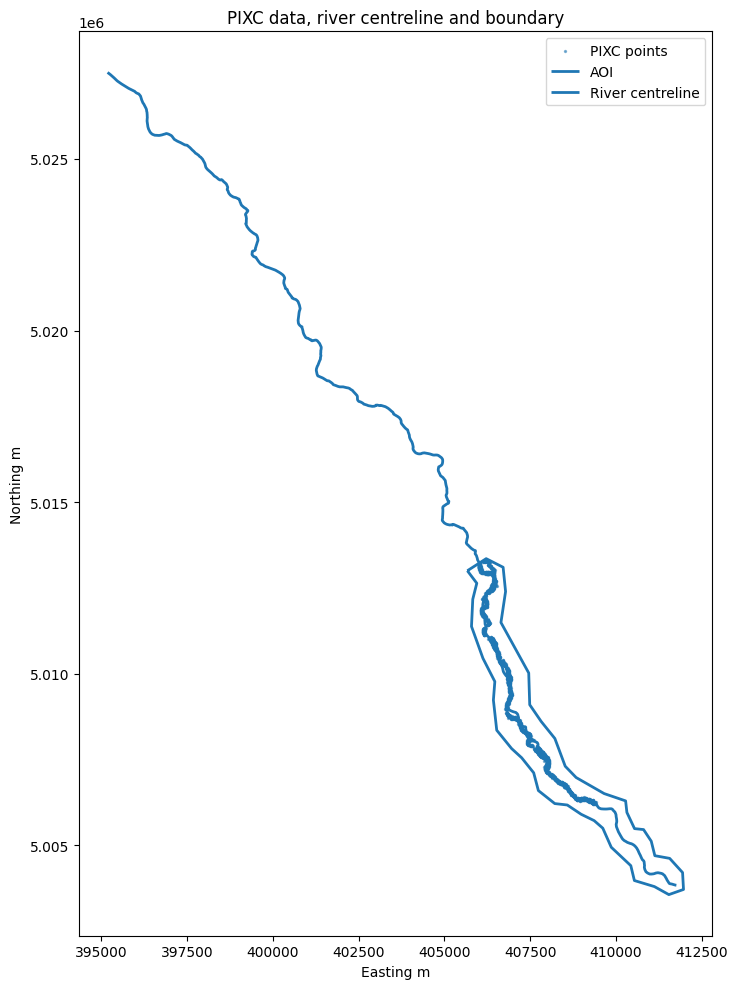

INFO | Saved overview figure to /content/orco_height_outputs/figures/01_data_overview.png


In [ ]:
#river map

#ive clipped the aoi and ive plotted the pixc points only in the aoi
#have used the centreline as our main ruver
#and overlayed aoi !!!!
#tbh if we want for full river we dont have to clip? just doing to reduce the points! - makes easier

#could perhaps zoom in j on aoi ? if neeeded so we can zoom in on the pixc points?

fig, ax = plt.subplots(figsize=(10, 10))

pixc_clean.plot(ax=ax, markersize=2, alpha=0.5, label="PIXC points")

river_boundary.boundary.plot(
    ax=ax, linewidth=2, label="AOI"
)

river_centreline.plot(ax=ax, linewidth=2, label="River centreline")

ax.set_title("PIXC data, river centreline and boundary")
ax.set_xlabel("Easting m")
ax.set_ylabel("Northing m")
ax.set_aspect("equal")
ax.legend()

plt.tight_layout()

overview_path = output_dirs["figures"] / "01_data_overview.png"
plt.savefig(overview_path, dpi=300, bbox_inches="tight")
plt.show()

logger.info("Saved overview figure to %s", overview_path)

In [ ]:
#centrelineeeeee and boundariesa

#we're saying here PLEASE can we have all our geom info the same type for each file
#j sorting out the line strings etc

def combine_geometries(gdf: gpd.GeoDataFrame, dataset_name: str):

    combined = gdf.geometry.union_all()

    if combined.is_empty: #if none = errorrr
        raise ValueError(f"{dataset_name} produced an empty geometry.")

    logger.info(
        "%s combined geometry type: %s", dataset_name, combined.geom_type
    )

    return combined


centreline_geometry = combine_geometries(river_centreline, "River centreline") #full gdf
boundary_geometry = combine_geometries(river_boundary, "AOI")

print("Centreline geometry type:", centreline_geometry.geom_type)
print("Boundary geometry type:", boundary_geometry.geom_type)


INFO | River centreline combined geometry type: LineString
INFO | AOI combined geometry type: Polygon


Centreline geometry type: LineString
Boundary geometry type: Polygon


In [ ]:
#ground track

def load_ground_track(
    file_path: Path,
    target_crs: str,
    longitude_column: str = "lon_sat",
    latitude_column: str = "lat_sat",
) -> gpd.GeoDataFrame: #proj again

    validate_file(file_path, "Satellite ground-track CSV") #its there? yay if yes error if no

    table = pd.read_csv(file_path) #reading

    missing = {longitude_column, latitude_column}.difference(table.columns) #what columns not there that we need

    if missing: #error if missing?
        raise KeyError(
            f"Ground-track CSV is missing columns: {sorted(missing)}"
        )

    track = gpd.GeoDataFrame( #our geom! this whole func basically makes our coord !!!
        table,
        geometry=gpd.points_from_xy(
            table[longitude_column], table[latitude_column]
        ),
        crs="EPSG:4326", #coords to lon lat again!
    )

    track = track.to_crs(target_crs) #proj ofc

    logger.info("Loaded %d satellite ground-track points", len(track))

    return track
#calling the func, now we basically have a set of coords that ww have from the csv from the rar file !!!

satellite_track = load_ground_track(
    config.ground_track_file,
    config.projected_crs,
)


INFO | Satellite ground-track CSV found: /content/sat_paths/sat_paths/SWOT_L2_HR_PIXC_031_029_234R_20250408T044534_20250408T044545_PGD0_01.csv
INFO | Loaded 23571 satellite ground-track points


In [ ]:
#getting our centreline on

def extract_centreline_segments(
    centreline_gdf: gpd.GeoDataFrame,
) -> gpd.GeoDataFrame:


    records = [] #setting an empty list as usual

    for geometry_id, geometry in enumerate(centreline_gdf.geometry):
        if geometry.geom_type == "LineString": #this is j accounting for linestring vs multistring!!!
            parts = [geometry]
        elif geometry.geom_type == "MultiLineString":
            parts = list(geometry.geoms)
        else: #again j making the code a bit more readable when and where its gone wrong
            raise TypeError(
                "Centreline geometry must be a LineString or "
                "MultiLineString."
            )

        for part_id, part in enumerate(parts): #this stuff is j what we had before to calc tha angles between the points!! nothing new
            coordinates = np.asarray(part.coords)

            if len(coordinates) < 2:
                continue

            x = coordinates[:, 0] #j selecting our coords and making x and y out of them
            y = coordinates[:, 1]

            dx = np.diff(x) #diff between adjacent coords!!
            dy = np.diff(y)

            angles_deg = np.degrees(np.arctan2(dy, dx)) #calc the angle between each adjacent point

            mid_x = (x[:-1] + x[1:]) / 2 #creating mps obv
            mid_y = (y[:-1] + y[1:]) / 2

            lengths_m = np.hypot(dx, dy) #finding the length between

            for local_index in range(len(angles_deg)): #j putting all info together
                records.append({
                    "geometry_id": geometry_id,
                    "part_id": part_id,
                    "local_segment_index": local_index,
                    "river_angle_deg": float(angles_deg[local_index]),
                    "segment_length_m": float(lengths_m[local_index]),
                    "geometry": Point(
                        mid_x[local_index], mid_y[local_index]
                    ),
                })

    if not records:
        raise ValueError("No valid centreline segments were created.")

    segments = gpd.GeoDataFrame( #segments means the dist bet two coords !! so this is literally me amking a data set of all our segments!
        records, geometry="geometry", crs=centreline_gdf.crs
    )

    segments["segment_index"] = np.arange(len(segments)) #putting in order!

    logger.info("Created %d centreline segments", len(segments)) #j another check in

    return segments


centreline_segments = extract_centreline_segments(river_centreline) #calling as usual



INFO | Created 865 centreline segments


In [ ]:
#ANGLES

#calc the satellite angle, this is again the same as before !!
def calculate_track_angle_deg(track: gpd.GeoDataFrame) -> float:


    if len(track) < 2:
        raise ValueError("At least two ground-track points are required.")

    x = track.geometry.x.to_numpy() #mking our coords here
    y = track.geometry.y.to_numpy()

    dx = x[-1] - x[0] #finding the diff in coords
    dy = y[-1] - y[0]


    angle_deg = float(np.degrees(np.arctan2(dy, dx))) #calc angle ofcccc

    logger.info("Satellite-track angle: %.2f deg", angle_deg) #put to 2dp cus before the amount of decimal places was j greedy

    return angle_deg


satellite_angle_deg = calculate_track_angle_deg(satellite_track) #calling!


INFO | Satellite-track angle: 73.76 deg


In [ ]:
#perp cands

#finding the difference in the anhgles and wrapping, again this is old stuff
def undirected_angle_difference_deg(
    angles_deg: np.ndarray,
    reference_angle_deg: float,
) -> np.ndarray:

    difference = np.abs(angles_deg - reference_angle_deg)
    difference = difference % 180.0
    difference = np.where(
        difference > 90.0, 180.0 - difference, difference
    )

    return difference

#we're basically saying how far away is our river angle from being perp to the ground track ?
#so we can use as a parameteer later !!!!
centreline_segments["angle_difference_deg"] = undirected_angle_difference_deg(
    centreline_segments["river_angle_deg"].to_numpy(),
    satellite_angle_deg,
)

centreline_segments["is_perpendicular_candidate"] = (
    np.abs(centreline_segments["angle_difference_deg"] - 90.0)
    <= config.angle_tolerance_deg
)


In [ ]:
#min runs!!!

def identify_perpendicular_runs(
    segments: gpd.GeoDataFrame,
    minimum_run_length: int,
) -> tuple[gpd.GeoDataFrame, gpd.GeoDataFrame]:


    accepted_indices = [] #initialising  - everything we keep !
    representative_indices = [] #middle segment that represents vthat run
    run_id = 0 #labelling them to keep track

    grouped = segments.groupby(["geometry_id", "part_id"], sort=False) #segments again but ordered
#this jusr keeps the segments sep so we can look at them individually !!!!!
    for _, group in grouped: #per group
        group = group.sort_values("local_segment_index") #sorting for consec!!!

        candidates = group.loc[group["is_perpendicular_candidate"]] #j the perp ones pls

        if candidates.empty: #if none, moves onto next group
            continue

        local_indices = candidates["local_segment_index"].to_numpy()

        split_locations = np.where(np.diff(local_indices) != 1)[0] + 1 #this tells us where the gaps are
#finding the diff in the local indices !1 so we then have an array of the diff
#if its not one then there is a gap
        runs = np.split(local_indices, split_locations) #splitting it up after the gaps

        for run in runs: #and that gives us our runss
            if len(run) < minimum_run_length: #igboire if too small ofc
                continue

            run_rows = group.loc[
                group["local_segment_index"].isin(run) #getting the actual data from the indices
            ]

            accepted_indices.extend(run_rows.index.tolist())

            middle_local_index = run[len(run) // 2] #find the middle of the perp run, basically finding the middle segment

            middle_row_index = group.loc[
                group["local_segment_index"] == middle_local_index
            ].index[0]

            representative_indices.append(middle_row_index) #this is so we just plot that middle val and not all the points in that perp run

            segments.loc[run_rows.index, "perpendicular_run_id"] = run_id

            run_id += 1 #j giving each run a number !!!! nice and ordered xx

    if not accepted_indices: #this is so if we have none we can backtrack, pretty optional but good to have (saves me printing everything)
        raise ValueError(
            "No perp consecutive segments!!"
        ) #tbh good if our tol angle is too strict

    accepted_segments = segments.loc[accepted_indices].copy() #dumping all that info into copies so its indep
    representative_midpoints = segments.loc[representative_indices].copy()

    logger.info(
        "Found %d stable perpendicular runs", len(representative_midpoints)
    ) #checkpointsssss

    return accepted_segments, representative_midpoints


perpendicular_segments, perpendicular_reaches = identify_perpendicular_runs(
    centreline_segments,
    config.minimum_perpendicular_run,
)
#calling as always


INFO | Found 38 stable perpendicular runs


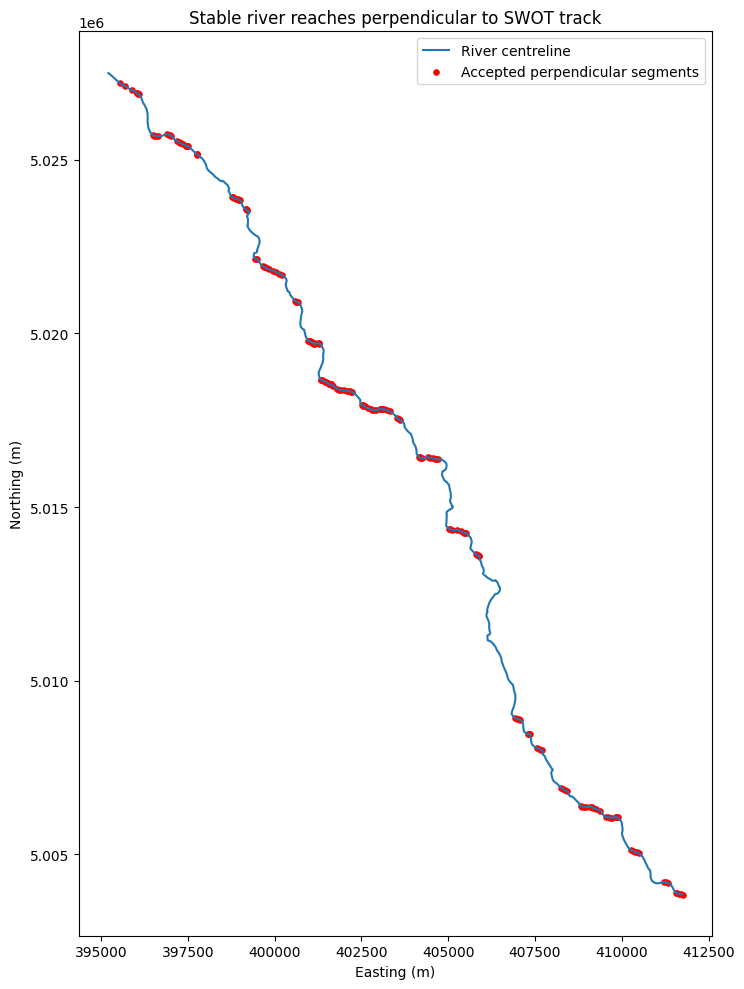

INFO | Saved perpendicular-reaches figure to /content/orco_height_outputs/figures/02_perpendicular_reaches.png


In [ ]:
#sexy plots

#same as before j ammeneded for the new funcs
fig, ax = plt.subplots(figsize=(10, 10))

river_centreline.plot(ax=ax, linewidth=1.5, label="River centreline")


perpendicular_segments.plot(
    ax=ax,
    markersize=14,
    label="Accepted perpendicular segments",
    c = "red" #j changed the colour here so we could see better, literlly is same as before
)




ax.set_aspect("equal")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("Stable river reaches perpendicular to SWOT track")
ax.legend()

plt.tight_layout()

perpendicular_reaches_path = (
    output_dirs["figures"] / "02_perpendicular_reaches.png"
)
plt.savefig(perpendicular_reaches_path, dpi=300, bbox_inches="tight")
plt.show() #saving our first figure with the new system !!!!

logger.info(
    "Saved perpendicular-reaches figure to %s", perpendicular_reaches_path
)




In [ ]:
#aoi shizzle
#j me clipping
#inspired by lucas

pixc_in_boundary = gpd.clip(pixc_clean, river_boundary).copy()





INFO | Chosen perpendicular reach segment: 783
INFO | Distance to nearest PIXC point: 2.95 m


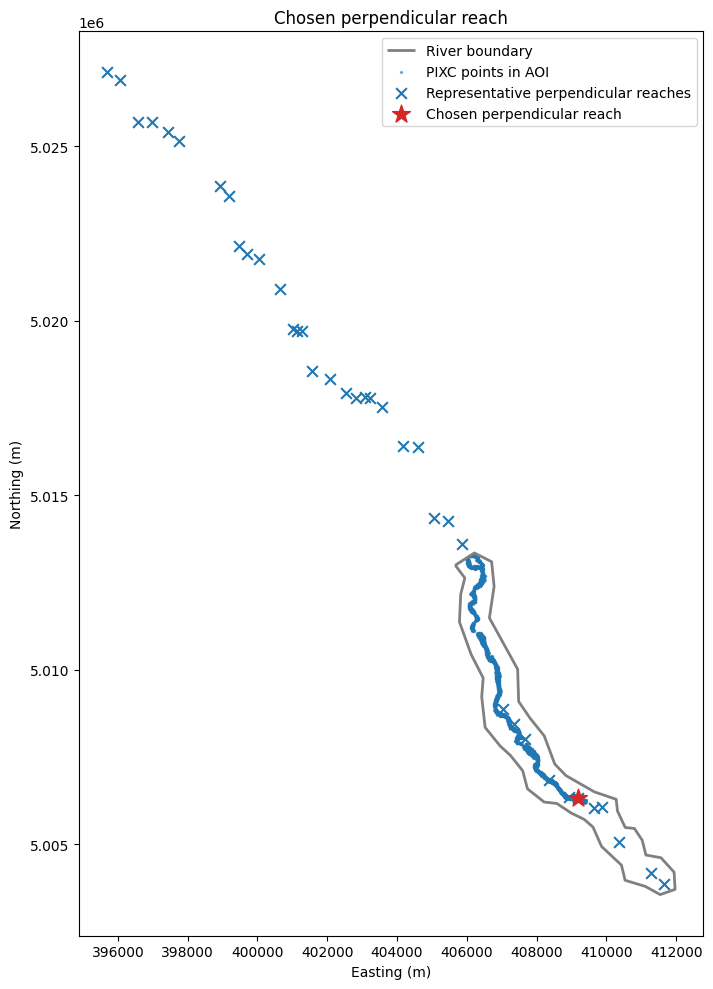

INFO | Saved chosen-reach figure to /content/orco_height_outputs/figures/03_chosen_perpendicular_reach.png


In [ ]:
#perp closest


def choose_reach_nearest_points(
    candidate_reaches: gpd.GeoDataFrame,
    points: gpd.GeoDataFrame,
    maximum_distance_m: float = 50.0,
) -> pd.Series:
    """
    Choose the perpendicular reach whose geometry is closest to any
    valid PIXC point.

    This avoids using the centroid of the full PIXC cloud, which can
    fall far from the actual river observations.
    """

    if candidate_reaches.empty:
        raise ValueError("No candidate reaches were supplied.")

    if points.empty:
        raise ValueError("No PIXC points were supplied.")

    if candidate_reaches.crs != points.crs:
        raise ValueError(
            "candidate_reaches and points must use the same CRS."
        )

    if not points.crs.is_projected:
        raise ValueError(
            "A projected CRS is required for metre-based distances."
        )

    minimum_distances = candidate_reaches.geometry.apply(
        lambda reach_point: points.geometry.distance(reach_point).min()
    )

    chosen_index = minimum_distances.idxmin()
    chosen_distance_m = float(minimum_distances.loc[chosen_index])

    if chosen_distance_m > maximum_distance_m:
        raise ValueError(
            "The nearest perpendicular reach is still "
            f"{chosen_distance_m:.2f} m from the nearest PIXC point. "
            f"The allowed maximum is {maximum_distance_m:.2f} m. "
            "Check that the centreline and PIXC data correspond to "
            "the same river section."
        )

    chosen = candidate_reaches.loc[chosen_index].copy()

    chosen["distance_to_nearest_pixc_m"] = chosen_distance_m

    logger.info(
        "Chosen perpendicular reach segment: %d",
        int(chosen["segment_index"]),
    )

    logger.info(
        "Distance to nearest PIXC point: %.2f m",
        chosen_distance_m,
    )

    return chosen

chosen_reach = choose_reach_nearest_points(
    candidate_reaches=perpendicular_reaches,
    points=pixc_in_boundary,
    maximum_distance_m=50.0,
)
chosen_centre_point = chosen_reach.geometry

chosen_river_angle_deg = float(
    chosen_reach["river_angle_deg"]
)

chosen_distance_to_nearest_pixc_m = float(
    chosen_reach["distance_to_nearest_pixc_m"]
)

chosen_segment_index = int(
    chosen_reach["segment_index"]
)

chosen_perpendicular_run_id = chosen_reach[
    "perpendicular_run_id"
]

fig, ax = plt.subplots(figsize=(10, 10))

river_boundary.boundary.plot(
    ax=ax, linewidth=2, color="grey", label="River boundary"
)

pixc_in_boundary.plot(
    ax=ax, markersize=2, alpha=0.5, label="PIXC points in AOI"
)

perpendicular_reaches.plot(
    ax=ax,
    markersize=60,
    marker="x",
    color="tab:blue",
    label="Representative perpendicular reaches",
)

gpd.GeoSeries([chosen_centre_point], crs=river_boundary.crs).plot(
    ax=ax,
    markersize=180,
    marker="*",
    color="tab:red",
    label="Chosen perpendicular reach",
)

ax.set_aspect("equal")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.set_title("Chosen perpendicular reach")
ax.legend()

plt.tight_layout()

chosen_reach_path = (
    output_dirs["figures"] / "03_chosen_perpendicular_reach.png"
)
plt.savefig(chosen_reach_path, dpi=300, bbox_inches="tight")
plt.show()

logger.info("Saved chosen-reach figure to %s", chosen_reach_path)



this part i want to go over cus its obv skewed due to points distrib, what does charlie think???

In [ ]:
#pick a point and river angle
#this whole cell is j checking stuff ibr

logger.info(
    "Chosen reach centre point (m): (%.2f, %.2f)",
    chosen_centre_point.x,
    chosen_centre_point.y,
)
logger.info("Chosen reach river angle: %.2f deg", chosen_river_angle_deg)
logger.info(
    "Distance from chosen reach to AOI PIXC centre: %.2f m",
    chosen_distance_to_pixc_centre_m,
)
logger.info("Chosen reach segment_index: %d", chosen_segment_index)
logger.info(
    "Chosen reach perpendicular_run_id: %s", chosen_perpendicular_run_id
)

print("\n=== Chosen perpendicular reach ===")
print(f"segment_index:            {chosen_segment_index}")
print(f"perpendicular_run_id:     {chosen_perpendicular_run_id}")
print(f"river_angle_deg:          {chosen_river_angle_deg:.2f}")
print(f"distance_to_pixc_centre_m:{chosen_distance_to_pixc_centre_m:.2f}")
print(f"centre_point (m):         ({chosen_centre_point.x:.2f}, "
      f"{chosen_centre_point.y:.2f})")

INFO | Chosen reach centre point (m): (407029.69, 5008883.08)
INFO | Chosen reach river angle: -16.39 deg
INFO | Distance from chosen reach to AOI PIXC centre: 598.69 m
INFO | Chosen reach segment_index: 694
INFO | Chosen reach perpendicular_run_id: 27.0



=== Chosen perpendicular reach ===
segment_index:            694
perpendicular_run_id:     27.0
river_angle_deg:          -16.39
distance_to_pixc_centre_m:598.69
centre_point (m):         (407029.69, 5008883.08)


In [ ]:
#geommm

def _unit_vector_deg(angle_deg: float) -> tuple[float, float]: #were turning our angles into vectors !!!!!


    return (
        float(np.cos(np.radians(angle_deg))),
        float(np.sin(np.radians(angle_deg))),
    )




In [ ]:
#cross sect geom

def build_cross_section_line(
    centre_point: Point, #defined previously
    river_angle_deg: float, #where on centreline
    half_length_m: float, #for cross sect either side
) -> LineString:


    if half_length_m <= 0:
        raise ValueError("half_length_m must be greater than zero.")

    if not isinstance(centre_point, Point) or centre_point.is_empty:
        raise ValueError("centre_point must be a non-empty shapely Point.")

    cross_section_angle_deg = river_angle_deg + 90.0 #were rotating so its across !
    ux, uy = _unit_vector_deg(cross_section_angle_deg) #again j angles into vectors

    dx = half_length_m * ux #scaling the vector for our lengths!!
    dy = half_length_m * uy

    line = LineString([ #THIS!!!!! is the big papa and makes our endpoints either side of the centre !
        (centre_point.x - dx, centre_point.y - dy),
        (centre_point.x + dx, centre_point.y + dy),
    ])

    logger.info(
        "Built cross-section line: river_angle=%.2f deg, "
        "cross_section_angle=%.2f deg, half_length=%.1f m",
        river_angle_deg,
        cross_section_angle_deg,
        half_length_m,
    )

    return line





cross_section_angle_deg = chosen_river_angle_deg + 90.0 #cross sect dir

cross_section_line = build_cross_section_line( #calling !!!
    centre_point=chosen_centre_point,
    river_angle_deg=chosen_river_angle_deg,
    half_length_m=config.cross_section_half_length_m,
)


INFO | Built cross-section line: river_angle=-16.39 deg, cross_section_angle=73.61 deg, half_length=500.0 m


In [ ]:
from dataclasses import dataclass
from shapely.geometry import Point, LineString

@dataclass(frozen=True)
class CrossSectionAnchors:
    centre: Point
    negative_edge: Point
    positive_edge: Point

In [ ]:
#edges!!!!!
#calling them our anchor points!


@dataclass(frozen=True) #getting info , our points are included here !!!
class CrossSectionGeometry:

    centre: Point
    negative_edge: Point
    positive_edge: Point
    cross_section_line: LineString #for the cross section line
    river_angle_deg: float
    cross_section_angle_deg: float
    negative_edge_distance_m: float
    positive_edge_distance_m: float
    river_width_m: float #this is us finding the total river width ! is j the sum of the pos and neg dist

#here we used a strip and said use the points in this strip to calc ! strip is pretty small.
def find_cross_section_anchors(
    pixc_points: gpd.GeoDataFrame,
    centre_point: Point,
    cross_section_angle_deg: float,
    strip_half_width_m: float = 10.0, #strip dim !
    search_half_length_m: float = 150.0,
) -> CrossSectionAnchors:


   #vector alaong cross section
    ux, uy = _unit_vector_deg(cross_section_angle_deg)
#same but perp to cross section, j done via translations
    vx, vy = -uy, ux

    x = pixc_points.geometry.x.to_numpy() #coords!
    y = pixc_points.geometry.y.to_numpy()

    #vector from centre to the points
    dx = x - centre_point.x
    dy = y - centre_point.y

    #across dist from positions!
    across_distance_m = dx * ux + dy * uy

    # Distance away from the cross-section line.
    distance_from_cross_section_m = dx * vx + dy * vy

    #if in our box
    mask = (
        (np.abs(distance_from_cross_section_m) <= strip_half_width_m)
        & (np.abs(across_distance_m) <= search_half_length_m)
    )

    selected_across_distances = across_distance_m[mask]

#we need at least 2 points in our box
    if len(selected_across_distances) < 2:
        raise ValueError(
            "Too few PIXC points were found near the cross-section."
        )

    negative_distances = selected_across_distances[
        selected_across_distances < 0
    ] #sep for neg and pos

    positive_distances = selected_across_distances[
        selected_across_distances > 0
    ]

    if len(negative_distances) == 0:
        raise ValueError(
            "No PIXC points were found on the negative side."
        )
#uh oh, for if the dist come out wring for neg vs pos
    if len(positive_distances) == 0:
        raise ValueError(
            "No PIXC points were found on the positive side."
        )

    #THIS Is the eDGE
    negative_edge_distance = negative_distances.min()
    positive_edge_distance = positive_distances.max()

    #this is literally calc the pos and neg edges !!!!
    negative_edge = Point(
        centre_point.x + negative_edge_distance * ux,
        centre_point.y + negative_edge_distance * uy,
    )

    positive_edge = Point(
        centre_point.x + positive_edge_distance * ux,
        centre_point.y + positive_edge_distance * uy,
    )

    logger.info( #checkpoints
        "PIXC-derived edges: %.2f m negative, %.2f m positive, "
        "using %d nearby points.",
        abs(negative_edge_distance),
        positive_edge_distance,
        len(selected_across_distances),
    )



    return CrossSectionAnchors(
        centre=centre_point,
        negative_edge=negative_edge,
        positive_edge=positive_edge,
    )


#again an interesting validation step!!

def validate_cross_section_geometry(
    anchors: CrossSectionAnchors,
    cross_section_line: LineString,
    river_angle_deg: float,
    cross_section_angle_deg: float,
) -> CrossSectionGeometry:
    """
    Validate a set of raw cross-section anchors and package them, with
    derived distances and river width, into a CrossSectionGeometry.
    """

    for label, point in ( #j labelling up here tbh
        ("centre", anchors.centre),
        ("negative_edge", anchors.negative_edge),
        ("positive_edge", anchors.positive_edge),
    ):
        if not isinstance(point, Point) or point.is_empty: #if its not correct get ridddddd
            raise ValueError(f"Cross-section anchor '{label}' is invalid.")

    ux, uy = _unit_vector_deg(cross_section_angle_deg) #makiung a vector !!

    def _signed_distance(point: Point) -> float:
        return (
            (point.x - anchors.centre.x) * ux
            + (point.y - anchors.centre.y) * uy
        )

    negative_signed_distance_m = _signed_distance(anchors.negative_edge)
    positive_signed_distance_m = _signed_distance(anchors.positive_edge)

    if negative_signed_distance_m >= 0: #basically saying yikes if this isnt on the neg side then raise and error cus then the neg step has failed!!!
        raise ValueError(
            "negative_edge does not have a negative signed distance "
            "from the centre; cross-section geometry is inconsistent."
        )

    if positive_signed_distance_m <= 0:
        raise ValueError(
            "positive_edge does not have a positive signed distance "
            "from the centre; cross-section geometry is inconsistent."
        )

    negative_edge_distance_m = abs(negative_signed_distance_m)
    positive_edge_distance_m = abs(positive_signed_distance_m)
    river_width_m = negative_edge_distance_m + positive_edge_distance_m #again j defining river width here !!

    if not np.isfinite(river_width_m) or river_width_m <= 0:
        raise ValueError(
            f"Derived river width is not physically plausible: "
            f"{river_width_m!r} m."
        )

    logger.info( #checkpoint !
        "Cross-section validated: width=%.2f m "
        "(negative=%.2f m, positive=%.2f m)",
        river_width_m,
        negative_edge_distance_m,
        positive_edge_distance_m,
    )

    return CrossSectionGeometry(
        centre=anchors.centre,
        negative_edge=anchors.negative_edge,
        positive_edge=anchors.positive_edge,
        cross_section_line=cross_section_line,
        river_angle_deg=river_angle_deg,
        cross_section_angle_deg=cross_section_angle_deg,
        negative_edge_distance_m=negative_edge_distance_m,
        positive_edge_distance_m=positive_edge_distance_m,
        river_width_m=river_width_m,
    )


anchors = find_cross_section_anchors(
    pixc_points=pixc_clean,
    centre_point=chosen_centre_point,
    cross_section_angle_deg=cross_section_angle_deg,
    strip_half_width_m=10.0,
    search_half_length_m=config.cross_section_half_length_m,
)

cross_section_geometry = validate_cross_section_geometry(
    anchors=anchors,
    cross_section_line=cross_section_line,
    river_angle_deg=chosen_river_angle_deg,
    cross_section_angle_deg=cross_section_angle_deg,
)



INFO | PIXC-derived edges: 45.92 m negative, 19.11 m positive, using 5 nearby points.
INFO | Cross-section validated: width=65.03 m (negative=45.92 m, positive=19.11 m)


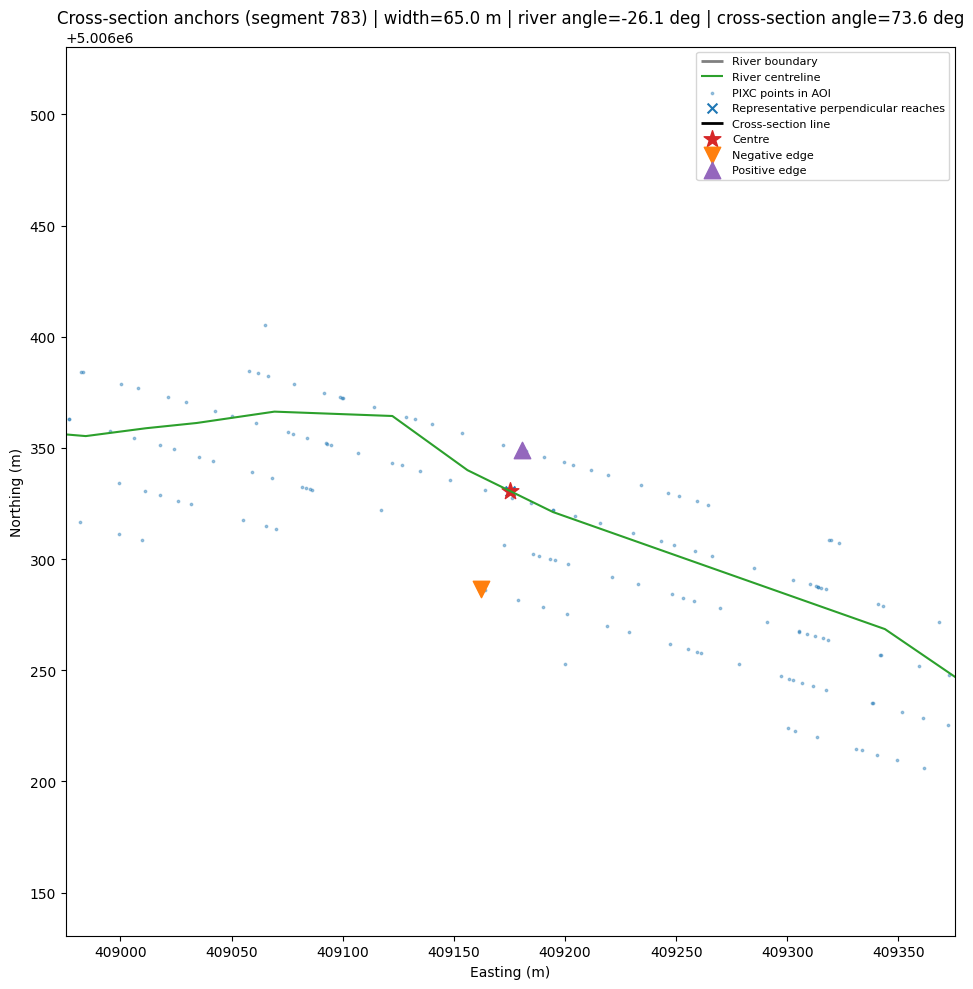

INFO | Saved cross-section figure to /content/orco_height_outputs/figures/04_cross_section_anchors.png


In [ ]:
#sexy plots pt 2

if config.save_figures:
    fig, ax = plt.subplots(figsize=(10, 10))

    river_boundary.boundary.plot(

        ax=ax, linewidth=2, color="grey", label="River boundary"
    )

    river_centreline.plot(
        ax=ax, linewidth=1.5, color="tab:green", label="River centreline"
    )

    pixc_in_boundary.plot(
        ax=ax, markersize=3, alpha=0.4, label="PIXC points in AOI"
    )

    perpendicular_reaches.plot(
        ax=ax,
        markersize=50,
        marker="x",
        color="tab:blue",
        label="Representative perpendicular reaches",
    )

    gpd.GeoSeries(
        [cross_section_geometry.cross_section_line], crs=river_boundary.crs
    ).plot(ax=ax, linewidth=2, color="black", label="Cross-section line")

    gpd.GeoSeries(
        [cross_section_geometry.centre], crs=river_boundary.crs
    ).plot(
        ax=ax, markersize=160, marker="*", color="tab:red", label="Centre"
    )

    gpd.GeoSeries(
        [cross_section_geometry.negative_edge], crs=river_boundary.crs
    ).plot(
        ax=ax,
        markersize=140,
        marker="v",
        color="tab:orange",
        label="Negative edge",
    )

    gpd.GeoSeries(
        [cross_section_geometry.positive_edge], crs=river_boundary.crs
    ).plot(
        ax=ax,
        markersize=140,
        marker="^",
        color="tab:purple",
        label="Positive edge",
    )

    zoom_m = config.cross_section_plot_zoom_m
    ax.set_xlim(
        chosen_centre_point.x - zoom_m, chosen_centre_point.x + zoom_m
    )
    ax.set_ylim(
        chosen_centre_point.y - zoom_m, chosen_centre_point.y + zoom_m
    )

    ax.set_aspect("equal")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_title(
        f"Cross-section anchors (segment {chosen_segment_index}) | "
        f"width={cross_section_geometry.river_width_m:.1f} m | "
        f"river angle={chosen_river_angle_deg:.1f} deg | "
        f"cross-section angle={cross_section_angle_deg:.1f} deg"
    )
    ax.legend(loc="best", fontsize=8)

    plt.tight_layout()

    cross_section_path = (
        output_dirs["figures"] / "04_cross_section_anchors.png"
    )
    plt.savefig(cross_section_path, dpi=300, bbox_inches="tight")
    plt.show()


    logger.info("Saved cross-section figure to %s", cross_section_path)
#here we have j plotted the river centgreline!! as well our cross section line !!

yikes that does not look ok, the centreline for whatever reason has been  plotted off the pixc points, want ti overlay !! perhaps the perp point we picked was wrong??

In [ ]:
#pixc stuff
#THISSSSSS!!!!! is where we select our points
def select_points_within_radius(
    points: gpd.GeoDataFrame,
    centre: Point,
    radius_m: float,
) -> gpd.GeoDataFrame:

#we're saying here !!!! lets pick the points in that radius pls, radius is obv config !

    if points.crs is None or not points.crs.is_projected: #j an error for if its not ?
        raise ValueError(#in case we havent proj but tbh optional cus we have proj code earlier !
            "select_points_within_radius requires points in a "
            "projected CRS for metre-based distances."
        )

    if radius_m <= 0: #classic but un likely, kind of j a foolproof, stops vals that have been put in wrong eg put in a - val!
        raise ValueError("radius_m must be greater than zero.")

    distance_m = points.geometry.distance(centre) #finding the distance from the proj coords
#this line is mega important - THISSSSS is the one i said about how we find the points in a certain config radius from a certain point !!
    selected = points.loc[distance_m <= radius_m].copy() #making an indep copy! with only suviving points
    selected["distance_to_anchor_m"] = distance_m.loc[selected.index] #and every point knows its dist from centre
#^^^ basically calcs dist from our chosen point and then filters for our config radius
    return selected
#this basically says i only want this for my little river section

pixc_local = select_points_within_radius( #our local pixc points!!!!! calling func
    points=pixc_clean,
    centre=chosen_centre_point,
    radius_m=config.local_search_radius_m,
)

#overall we basically take all of our pixc, and a circle on chosen loc and keep points in that circle
logger.info("Total valid PIXC points (pixc_clean): %d", len(pixc_clean)) #again j checking for clean points
logger.info("Valid PIXC points inside AOI (pixc_in_boundary): %d", len(pixc_in_boundary))
logger.info(
    "Valid PIXC points within local_search_radius_m of the chosen "
    "reach (pixc_local): %d",
    len(pixc_local),
)

#this is just for local subsets so far


INFO | Total valid PIXC points (pixc_clean): 2630
INFO | Valid PIXC points inside AOI (pixc_in_boundary): 2630
INFO | Valid PIXC points within local_search_radius_m of the chosen reach (pixc_local): 249


go over

In [ ]:
#for the local height
#this cell includes a lot of stat checks tbh


@dataclass(frozen=True)
class LocalHeightSummary:
    #these are literally height stats per anchor for that area !

    anchor_label: str #which anchor we've used
    radius_m: float #and for what radius
    n_points: int #number of points in that radius !!!!
    mean_height_m: float
    median_height_m: float #more heigh stats tbh
    standard_deviation_m: float
    minimum_height_m: float
    maximum_height_m: float
    mad_m: float
    standard_error_m: float
    anchor_x_m: float
    anchor_y_m: float


def summarise_local_height(
    sample: gpd.GeoDataFrame,
    anchor_label: str,
    radius_m: float,
    height_column: str,
    anchor: Point,
) -> LocalHeightSummary: #also tells us about the Nans so we can see how to treat ? and decide later on.

    heights = pd.to_numeric(sample[height_column], errors="coerce")
    heights = heights.replace([np.inf, -np.inf], np.nan).dropna()# getting rid of silly NaNs

    n_points = len(heights) #this is oiur number of points, just taken from the height info

    if n_points == 0: #if theres no points, basically returninhg nans so that we can adjust
        return LocalHeightSummary( #tbh i might change this to just a standard error with a specific reason for the error
            anchor_label=anchor_label, #cus if theres no points we need to expand our search radius !!
            radius_m=radius_m,
            n_points=0,
            mean_height_m=np.nan,
            median_height_m=np.nan,
            standard_deviation_m=np.nan,
            minimum_height_m=np.nan,
            maximum_height_m=np.nan,
            mad_m=np.nan,
            standard_error_m=np.nan,
            anchor_x_m=float(anchor.x),
            anchor_y_m=float(anchor.y),
        )

    mean_height_m = float(heights.mean()) #j calc here
    median_height_m = float(heights.median())
    minimum_height_m = float(heights.min())
    maximum_height_m = float(heights.max())
    mad_m = float((heights - median_height_m).abs().median())  #check is ok!

    if n_points >= 2: #we need for than 2 points in our radii
        standard_deviation_m = float(heights.std(ddof=1))
        standard_error_m = standard_deviation_m / np.sqrt(n_points)
    else:#if not get rid !
        standard_deviation_m = np.nan
        standard_error_m = np.nan

    return LocalHeightSummary(
        anchor_label=anchor_label,
        radius_m=radius_m,
        n_points=n_points,
        mean_height_m=mean_height_m,
        median_height_m=median_height_m,
        standard_deviation_m=standard_deviation_m,
        minimum_height_m=minimum_height_m,
        maximum_height_m=maximum_height_m,
        mad_m=mad_m,
        standard_error_m=standard_error_m,
        anchor_x_m=float(anchor.x),
        anchor_y_m=float(anchor.y),
    )


def _neighbourhood_status( #this will tell us how many points are giving us info
    summaries: dict[str, LocalHeightSummary],#so if theres not enough it will say cus obv small sample set - will be rlly skewed !
    minimum_sample_points: int,
) -> tuple[dict[str, bool], str]:

    passes = { #if we have above the min number of points  and storing
        label: summary.n_points >= minimum_sample_points
        for label, summary in summaries.items()
    }

    if any(summary.n_points == 0 for summary in summaries.values()):
        status = "no_points" #if no pints
    elif not all(passes.values()): #if below the min points
        status = "insufficient_points"
    else:
        status = "ok" #pass!

    return passes, status


def _count_shared_points( #the points we have that are in two anchor locals,
    sample_a: gpd.GeoDataFrame, sample_b: gpd.GeoDataFrame #for example if our radius is rlly large then we wil have overlapping points
) -> int:
    #this j makes a dataset of them

    return int(len(sample_a.index.intersection(sample_b.index)))




In [ ]:
#delta h
#finally getting onto iy!

#this finds the delta h between the pos and neg side vs the centreline
@dataclass(frozen=True)
class DeltaHeightResult:

    radius_m: float #for what radius !!

    centre: LocalHeightSummary
    negative_edge: LocalHeightSummary
    positive_edge: LocalHeightSummary

    delta_h_negative_mean_m: float #the mean delta h
    delta_h_positive_mean_m: float

    delta_h_negative_median_m: float
    delta_h_positive_median_m: float

    delta_h_negative_mean_sem_m: float
    delta_h_positive_mean_sem_m: float

    negative_neighbourhood_passes: bool #is it ok? does it pass our tests?
    centre_neighbourhood_passes: bool
    positive_neighbourhood_passes: bool

    neighbourhoods_overlap: bool #dp we have overlapping points?
    n_shared_negative_centre: int
    n_shared_centre_positive: int
    n_shared_negative_positive: int

    status: str


def analyse_cross_section_height( #thisssss then finds the height in our anchor local areas
               #this gives local geight in out little area
    pixc_points: gpd.GeoDataFrame,
    geometry: CrossSectionGeometry,
    radius_m: float,
    minimum_sample_points: int,
    height_column: str,#(mean and median in previous cell)
) -> DeltaHeightResult: #have done both mean and median because mean can be extreme skewed?
  #tbh mean is fine if we inspect or filter out outliers but median is just safer and gives sim result,
  #could POTENTIALLY add a line or two to compare but extra code for not much back

    negative_sample = select_points_within_radius(
        pixc_points, geometry.negative_edge, radius_m
    )
    centre_sample = select_points_within_radius(
        pixc_points, geometry.centre, radius_m
    )
    positive_sample = select_points_within_radius(
        pixc_points, geometry.positive_edge, radius_m
    )

    negative_summary = summarise_local_height(
        negative_sample, "negative_edge", radius_m, height_column,
        geometry.negative_edge,
    )
    centre_summary = summarise_local_height(
        centre_sample, "centre", radius_m, height_column, geometry.centre,
    )
    positive_summary = summarise_local_height(
        positive_sample, "positive_edge", radius_m, height_column,
        geometry.positive_edge,
    )
#this then gives delta h !!!
    def _delta(edge_value: float, centre_value: float) -> float:
        if np.isnan(edge_value) or np.isnan(centre_value): #if nan values !!
            return np.nan
        return float(edge_value - centre_value) #otherwise gives us our delta h

    delta_h_negative_mean_m = _delta(
        negative_summary.mean_height_m, centre_summary.mean_height_m
    )
    delta_h_positive_mean_m = _delta(
        positive_summary.mean_height_m, centre_summary.mean_height_m
    )
    delta_h_negative_median_m = _delta(
        negative_summary.median_height_m, centre_summary.median_height_m
    )
    delta_h_positive_median_m = _delta(
        positive_summary.median_height_m, centre_summary.median_height_m
    )

    def _propagated_sem(edge_summary: LocalHeightSummary) -> float:
        if np.isnan(edge_summary.standard_error_m) or np.isnan(
            centre_summary.standard_error_m
        ):
            return np.nan
        return float(np.sqrt(
            edge_summary.standard_error_m ** 2
            + centre_summary.standard_error_m ** 2
        ))

    delta_h_negative_mean_sem_m = _propagated_sem(negative_summary)
    delta_h_positive_mean_sem_m = _propagated_sem(positive_summary)

    passes, status = _neighbourhood_status(
        {
            "negative_edge": negative_summary,
            "centre": centre_summary,
            "positive_edge": positive_summary,
        },
        minimum_sample_points,
    )

    #this is to sort out overlaps ? cus bit of a toughy but are j using in both for height meas
    negative_centre_distance_m = geometry.negative_edge.distance(
        geometry.centre
    )
    centre_positive_distance_m = geometry.centre.distance(
        geometry.positive_edge
    )
    negative_positive_distance_m = geometry.negative_edge.distance(
        geometry.positive_edge
    )

    neighbourhoods_overlap = (
        negative_centre_distance_m < 2 * radius_m
        or centre_positive_distance_m < 2 * radius_m
        or negative_positive_distance_m < 2 * radius_m
    )

    n_shared_negative_centre = _count_shared_points(
        negative_sample, centre_sample
    )
    n_shared_centre_positive = _count_shared_points(
        centre_sample, positive_sample
    )
    n_shared_negative_positive = _count_shared_points(
        negative_sample, positive_sample
    )

    if neighbourhoods_overlap:
        logger.warning(
            "Anchor neighbourhoods overlap at radius_m=%.1f "
            "(shared points: negative-centre=%d, centre-positive=%d, "
            "negative-positive=%d). Samples are not fully independent.",
            radius_m,
            n_shared_negative_centre,
            n_shared_centre_positive,
            n_shared_negative_positive,
        )

    if status != "ok":
        logger.warning(
            "Radius %.1f m: neighbourhood status='%s' "
            "(n_negative=%d, n_centre=%d, n_positive=%d, "
            "minimum_sample_points=%d)",
            radius_m,
            status,
            negative_summary.n_points,
            centre_summary.n_points,
            positive_summary.n_points,
            minimum_sample_points,
        )

    return DeltaHeightResult(
        radius_m=radius_m,
        centre=centre_summary,
        negative_edge=negative_summary,
        positive_edge=positive_summary,
        delta_h_negative_mean_m=delta_h_negative_mean_m,
        delta_h_positive_mean_m=delta_h_positive_mean_m,
        delta_h_negative_median_m=delta_h_negative_median_m,
        delta_h_positive_median_m=delta_h_positive_median_m,
        delta_h_negative_mean_sem_m=delta_h_negative_mean_sem_m,
        delta_h_positive_mean_sem_m=delta_h_positive_mean_sem_m,
        negative_neighbourhood_passes=passes["negative_edge"],
        centre_neighbourhood_passes=passes["centre"],
        positive_neighbourhood_passes=passes["positive_edge"],
        neighbourhoods_overlap=neighbourhoods_overlap,
        n_shared_negative_centre=n_shared_negative_centre,
        n_shared_centre_positive=n_shared_centre_positive,
        n_shared_negative_positive=n_shared_negative_positive,
        status=status,
    )


primary_result = analyse_cross_section_height(
    pixc_points=pixc_local,
    geometry=cross_section_geometry,
    radius_m=config.sample_radius_m,
    minimum_sample_points=config.minimum_sample_points,
    height_column=config.height_column,
)

logger.info(
    "Primary radius (%.1f m) delta h: negative_mean=%.4f m, "
    "positive_mean=%.4f m, negative_median=%.4f m, "
    "positive_median=%.4f m, status=%s",
    primary_result.radius_m,
    primary_result.delta_h_negative_mean_m,
    primary_result.delta_h_positive_mean_m,
    primary_result.delta_h_negative_median_m,
    primary_result.delta_h_positive_median_m,
    primary_result.status,
)


WARNING | Anchor neighbourhoods overlap at radius_m=20.0 (shared points: negative-centre=0, centre-positive=1, negative-positive=0). Samples are not fully independent.
WARNING | Radius 20.0 m: neighbourhood status='insufficient_points' (n_negative=2, n_centre=4, n_positive=4, minimum_sample_points=10)
INFO | Primary radius (20.0 m) delta h: negative_mean=0.1551 m, positive_mean=0.0180 m, negative_median=0.1555 m, positive_median=0.0285 m, status=insufficient_points


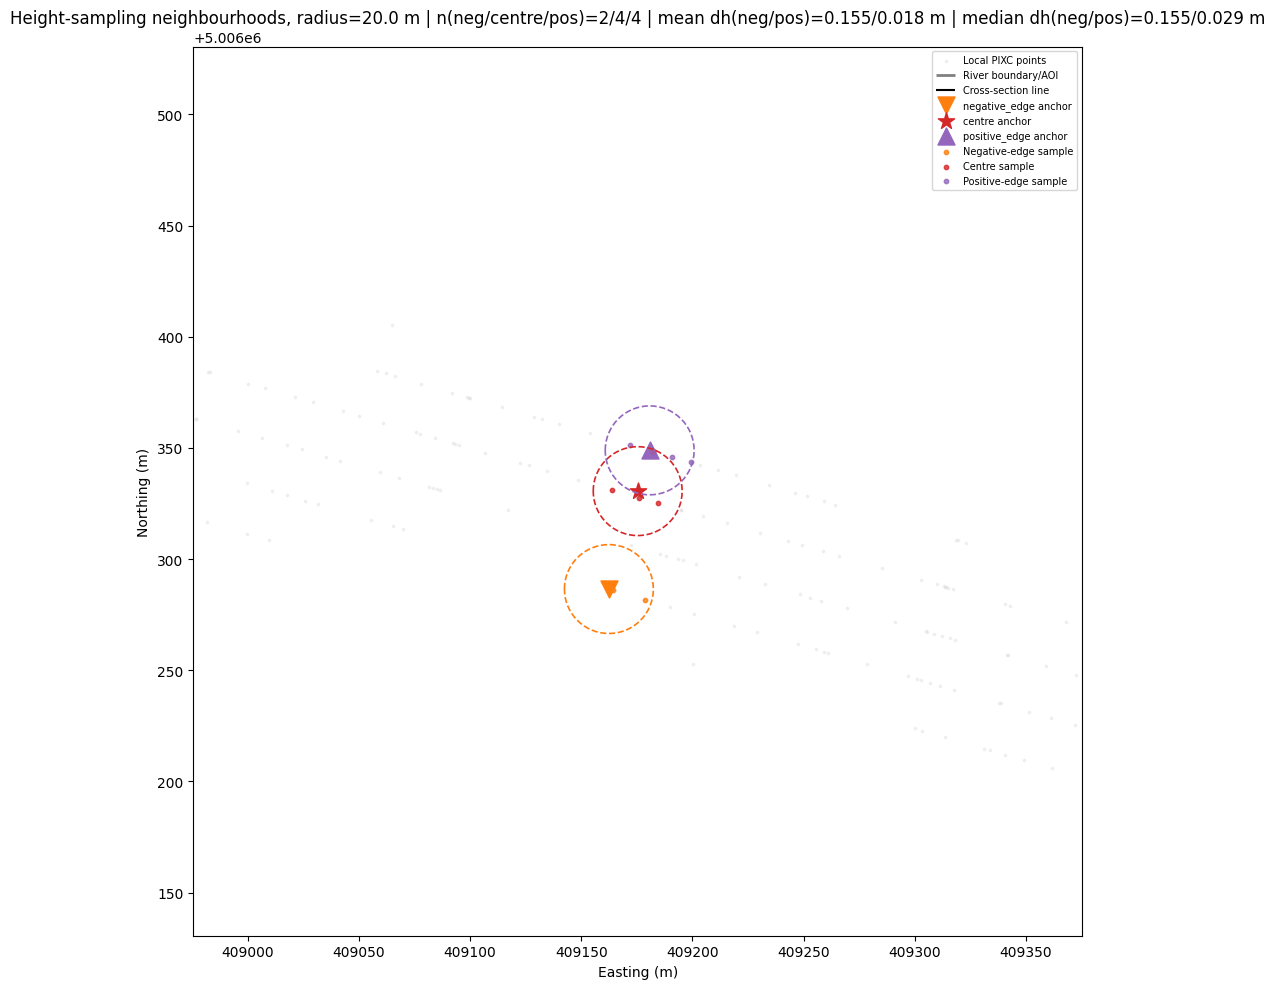

INFO | Saved sampling-neighbourhoods figure to /content/orco_height_outputs/figures/05_height_sampling_neighbourhoods.png


In [ ]:
#plots!

def _local_sample_for_anchor(
    pixc_points: gpd.GeoDataFrame, anchor: Point, radius_m: float
) -> gpd.GeoDataFrame:
    """Convenience wrapper reused for plotting the primary-radius samples."""

    return select_points_within_radius(pixc_points, anchor, radius_m)


if config.save_figures:
    negative_sample_primary = _local_sample_for_anchor(
        pixc_local, cross_section_geometry.negative_edge, config.sample_radius_m
    )
    centre_sample_primary = _local_sample_for_anchor(
        pixc_local, cross_section_geometry.centre, config.sample_radius_m
    )
    positive_sample_primary = _local_sample_for_anchor(
        pixc_local, cross_section_geometry.positive_edge, config.sample_radius_m
    )

    fig, ax = plt.subplots(figsize=(10, 10))

    pixc_local.plot(
        ax=ax, markersize=3, alpha=0.25, color="lightgrey",
        label="Local PIXC points",
    )

    river_boundary.boundary.plot(
        ax=ax, linewidth=2, color="grey", label="River boundary/AOI"
    )

    gpd.GeoSeries(
        [cross_section_geometry.cross_section_line], crs=river_boundary.crs
    ).plot(ax=ax, linewidth=1.5, color="black", label="Cross-section line")

    anchor_styles = {
        "negative_edge": (
            cross_section_geometry.negative_edge, "tab:orange", "v",
        ),
        "centre": (cross_section_geometry.centre, "tab:red", "*"),
        "positive_edge": (
            cross_section_geometry.positive_edge, "tab:purple", "^",
        ),
    }

    for label, (anchor, colour, marker) in anchor_styles.items():
        gpd.GeoSeries([anchor], crs=river_boundary.crs).plot(
            ax=ax, markersize=150, marker=marker, color=colour,
            label=f"{label} anchor",
        )
        gpd.GeoSeries(
            [anchor.buffer(config.sample_radius_m)], crs=river_boundary.crs
        ).boundary.plot(ax=ax, linewidth=1.2, color=colour, linestyle="--")

    negative_sample_primary.plot(
        ax=ax, markersize=10, color="tab:orange", alpha=0.8,
        label="Negative-edge sample",
    )
    centre_sample_primary.plot(
        ax=ax, markersize=10, color="tab:red", alpha=0.8,
        label="Centre sample",
    )
    positive_sample_primary.plot(
        ax=ax, markersize=10, color="tab:purple", alpha=0.8,
        label="Positive-edge sample",
    )

    zoom_m = max(
        config.cross_section_plot_zoom_m,
        cross_section_geometry.river_width_m,
    )
    ax.set_xlim(
        chosen_centre_point.x - zoom_m, chosen_centre_point.x + zoom_m
    )
    ax.set_ylim(
        chosen_centre_point.y - zoom_m, chosen_centre_point.y + zoom_m
    )

    ax.set_aspect("equal")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_title(
        f"Height-sampling neighbourhoods, radius={config.sample_radius_m:.1f} m | "
        f"n(neg/centre/pos)="
        f"{primary_result.negative_edge.n_points}/"
        f"{primary_result.centre.n_points}/"
        f"{primary_result.positive_edge.n_points} | "
        f"mean dh(neg/pos)="
        f"{primary_result.delta_h_negative_mean_m:.3f}/"
        f"{primary_result.delta_h_positive_mean_m:.3f} m | "
        f"median dh(neg/pos)="
        f"{primary_result.delta_h_negative_median_m:.3f}/"
        f"{primary_result.delta_h_positive_median_m:.3f} m"
    )
    ax.legend(loc="best", fontsize=7)

    plt.tight_layout()

    neighbourhoods_path = (
        output_dirs["figures"] / "05_height_sampling_neighbourhoods.png"
    )
    plt.savefig(neighbourhoods_path, dpi=300, bbox_inches="tight")
    plt.show()

    logger.info("Saved sampling-neighbourhoods figure to %s", neighbourhoods_path)



In [ ]:
def _result_to_row(result: DeltaHeightResult) -> dict:
    """Flatten one DeltaHeightResult into a single results-table row."""

    return {
        "radius_m": result.radius_m,
        "n_negative_edge": result.negative_edge.n_points,
        "n_centre": result.centre.n_points,
        "n_positive_edge": result.positive_edge.n_points,
        "mean_height_negative_m": result.negative_edge.mean_height_m,
        "mean_height_centre_m": result.centre.mean_height_m,
        "mean_height_positive_m": result.positive_edge.mean_height_m,
        "median_height_negative_m": result.negative_edge.median_height_m,
        "median_height_centre_m": result.centre.median_height_m,
        "median_height_positive_m": result.positive_edge.median_height_m,
        "std_negative_m": result.negative_edge.standard_deviation_m,
        "std_centre_m": result.centre.standard_deviation_m,
        "std_positive_m": result.positive_edge.standard_deviation_m,
        "sem_negative_m": result.negative_edge.standard_error_m,
        "sem_centre_m": result.centre.standard_error_m,
        "sem_positive_m": result.positive_edge.standard_error_m,
        "delta_h_negative_mean_m": result.delta_h_negative_mean_m,
        "delta_h_positive_mean_m": result.delta_h_positive_mean_m,
        "delta_h_negative_median_m": result.delta_h_negative_median_m,
        "delta_h_positive_median_m": result.delta_h_positive_median_m,
        "delta_h_negative_mean_sem_m": result.delta_h_negative_mean_sem_m,
        "delta_h_positive_mean_sem_m": result.delta_h_positive_mean_sem_m,
        "negative_passes_minimum": result.negative_neighbourhood_passes,
        "centre_passes_minimum": result.centre_neighbourhood_passes,
        "positive_passes_minimum": result.positive_neighbourhood_passes,
        "neighbourhoods_overlap": result.neighbourhoods_overlap,
        "n_shared_negative_centre": result.n_shared_negative_centre,
        "n_shared_centre_positive": result.n_shared_centre_positive,
        "n_shared_negative_positive": result.n_shared_negative_positive,
        "status": result.status,
    }


def analyse_radius_sensitivity(
    pixc_points: gpd.GeoDataFrame,
    geometry: CrossSectionGeometry,
    radii_m: tuple[float, ...],
    minimum_sample_points: int,
    height_column: str,
) -> pd.DataFrame:
    """
    Repeat analyse_cross_section_height across several radii to assess
    the stability of the delta-height result.

    This is a sensitivity diagnostic, not a source of independent
    observations: neighbouring radii reuse largely the same PIXC
    points. Processing continues across all radii even if one radius
    yields insufficient data at some anchor.
    """

    rows = []

    for radius_m in radii_m:
        try:
            result = analyse_cross_section_height(
                pixc_points=pixc_points,
                geometry=geometry,
                radius_m=radius_m,
                minimum_sample_points=minimum_sample_points,
                height_column=height_column,
            )
            rows.append(_result_to_row(result))
        except ValueError as error:
            logger.warning(
                "Radius %.1f m could not be analysed: %s", radius_m, error
            )

    if not rows:
        raise ValueError(
            "No radius in sensitivity_radii_m produced a usable result."
        )

    table = pd.DataFrame(rows).sort_values("radius_m").reset_index(drop=True)

    return table


radius_sensitivity_table = analyse_radius_sensitivity(
    pixc_points=pixc_local,
    geometry=cross_section_geometry,
    radii_m=config.sensitivity_radii_m,
    minimum_sample_points=config.minimum_sample_points,
    height_column=config.height_column,
)



WARNING | Radius 5.0 m: neighbourhood status='insufficient_points' (n_negative=1, n_centre=1, n_positive=1, minimum_sample_points=10)
WARNING | Anchor neighbourhoods overlap at radius_m=10.0 (shared points: negative-centre=0, centre-positive=0, negative-positive=0). Samples are not fully independent.
WARNING | Radius 10.0 m: neighbourhood status='insufficient_points' (n_negative=1, n_centre=1, n_positive=2, minimum_sample_points=10)
WARNING | Anchor neighbourhoods overlap at radius_m=15.0 (shared points: negative-centre=0, centre-positive=0, negative-positive=0). Samples are not fully independent.
WARNING | Radius 15.0 m: neighbourhood status='insufficient_points' (n_negative=1, n_centre=3, n_positive=3, minimum_sample_points=10)
WARNING | Anchor neighbourhoods overlap at radius_m=20.0 (shared points: negative-centre=0, centre-positive=1, negative-positive=0). Samples are not fully independent.
WARNING | Radius 20.0 m: neighbourhood status='insufficient_points' (n_negative=2, n_centre=

In [ ]:
#saving!

radius_sensitivity_csv_path = (
    output_dirs["tables"] / "delta_h_radius_sensitivity.csv"
)
radius_sensitivity_table.to_csv(radius_sensitivity_csv_path, index=False)
logger.info("Saved radius-sensitivity table to %s", radius_sensitivity_csv_path)

primary_radius_row = _result_to_row(primary_result)
primary_radius_row.update({
    "segment_index": chosen_segment_index,
    "perpendicular_run_id": chosen_perpendicular_run_id,
    "river_angle_deg": chosen_river_angle_deg,
    "cross_section_angle_deg": cross_section_geometry.cross_section_angle_deg,
    "river_width_m": cross_section_geometry.river_width_m,
})
primary_radius_table = pd.DataFrame([primary_radius_row])

primary_radius_csv_path = (
    output_dirs["tables"] / "delta_h_primary_radius.csv"
)
primary_radius_table.to_csv(primary_radius_csv_path, index=False)
logger.info("Saved primary-radius summary table to %s", primary_radius_csv_path)


INFO | Saved radius-sensitivity table to /content/orco_height_outputs/tables/delta_h_radius_sensitivity.csv
INFO | Saved primary-radius summary table to /content/orco_height_outputs/tables/delta_h_primary_radius.csv


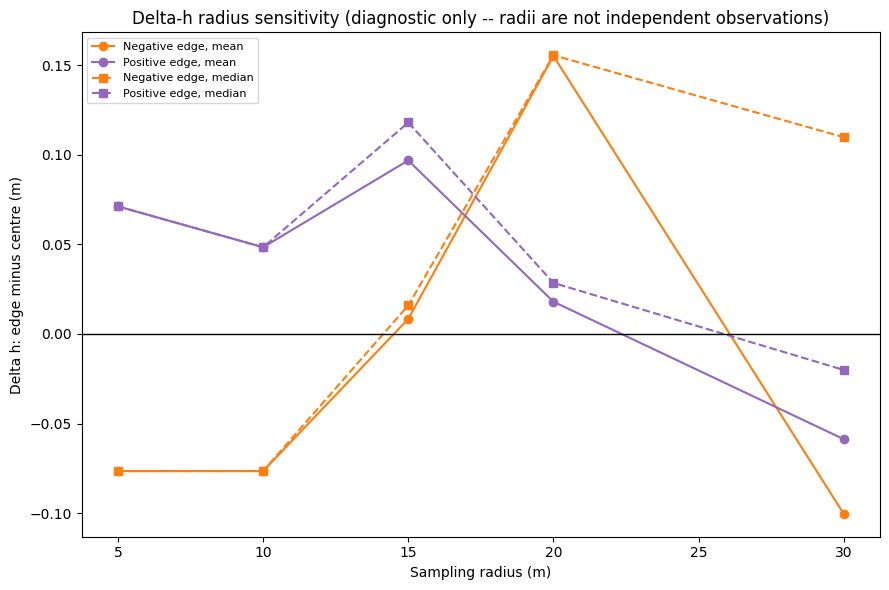

INFO | Saved delta-h sensitivity figure to /content/orco_height_outputs/figures/07_delta_h_radius_sensitivity.png


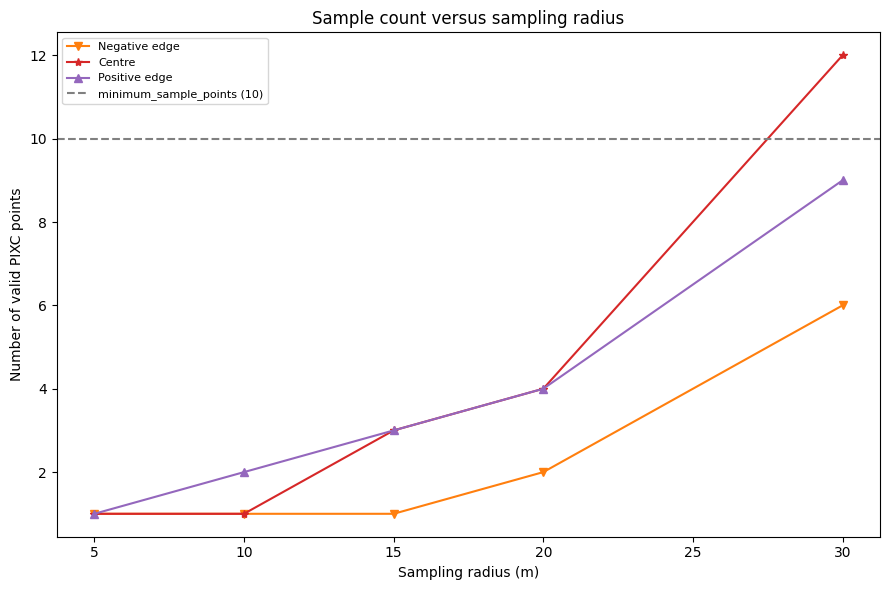

INFO | Saved sample-count sensitivity figure to /content/orco_height_outputs/figures/08_sample_count_radius_sensitivity.png


In [ ]:
#plot r sens

if config.save_figures:
    fig, ax = plt.subplots(figsize=(9, 6))

    ax.plot(
        radius_sensitivity_table["radius_m"],
        radius_sensitivity_table["delta_h_negative_mean_m"],
        marker="o", color="tab:orange", linestyle="-",
        label="Negative edge, mean",
    )
    ax.plot(
        radius_sensitivity_table["radius_m"],
        radius_sensitivity_table["delta_h_positive_mean_m"],
        marker="o", color="tab:purple", linestyle="-",
        label="Positive edge, mean",
    )
    ax.plot(
        radius_sensitivity_table["radius_m"],
        radius_sensitivity_table["delta_h_negative_median_m"],
        marker="s", color="tab:orange", linestyle="--",
        label="Negative edge, median",
    )
    ax.plot(
        radius_sensitivity_table["radius_m"],
        radius_sensitivity_table["delta_h_positive_median_m"],
        marker="s", color="tab:purple", linestyle="--",
        label="Positive edge, median",
    )

    ax.axhline(0.0, color="black", linewidth=1.0)

    ax.set_xlabel("Sampling radius (m)")
    ax.set_ylabel("Delta h: edge minus centre (m)")
    ax.set_title(
        "Delta-h radius sensitivity (diagnostic only -- radii are not "
        "independent observations)"
    )
    ax.legend(loc="best", fontsize=8)

    plt.tight_layout()

    sensitivity_path = (
        output_dirs["figures"] / "07_delta_h_radius_sensitivity.png"
    )
    plt.savefig(sensitivity_path, dpi=300, bbox_inches="tight")
    plt.show()

    logger.info("Saved delta-h sensitivity figure to %s", sensitivity_path)



if config.save_figures:
    fig, ax = plt.subplots(figsize=(9, 6))

    ax.plot(
        radius_sensitivity_table["radius_m"],
        radius_sensitivity_table["n_negative_edge"],
        marker="v", color="tab:orange", label="Negative edge",
    )
    ax.plot(
        radius_sensitivity_table["radius_m"],
        radius_sensitivity_table["n_centre"],
        marker="*", color="tab:red", label="Centre",
    )
    ax.plot(
        radius_sensitivity_table["radius_m"],
        radius_sensitivity_table["n_positive_edge"],
        marker="^", color="tab:purple", label="Positive edge",
    )

    ax.axhline(
        config.minimum_sample_points,
        color="grey", linestyle="--",
        label=f"minimum_sample_points ({config.minimum_sample_points})",
    )

    ax.set_xlabel("Sampling radius (m)")
    ax.set_ylabel("Number of valid PIXC points")
    ax.set_title("Sample count versus sampling radius")
    ax.legend(loc="best", fontsize=8)

    plt.tight_layout()

    sample_count_path = (
        output_dirs["figures"] / "08_sample_count_radius_sensitivity.png"
    )
    plt.savefig(sample_count_path, dpi=300, bbox_inches="tight")
    plt.show()

    logger.info("Saved sample-count sensitivity figure to %s", sample_count_path)


In [ ]:
#summary

def _format_value(value: float, decimals: int = 3) -> str:
    """Format a float for the printed summary, handling NaN cleanly."""

    if value is None or (isinstance(value, float) and np.isnan(value)):
        return "NaN"
    return f"{value:.{decimals}f}"


summary_lines = [
    "",
    "=== Delta-height run summary ===",
    "",
    "Chosen perpendicular reach",
    "--------------------------",
    f"Segment index:        {chosen_segment_index}",
    f"Run ID:               {chosen_perpendicular_run_id}",
    f"Local river angle:    {_format_value(chosen_river_angle_deg, 2)} deg",
    f"Cross-section angle:  {_format_value(cross_section_geometry.cross_section_angle_deg, 2)} deg",
    f"Estimated river width:{_format_value(cross_section_geometry.river_width_m, 2)} m",
    "",
    f"Primary sampling radius: {config.sample_radius_m:.1f} m",
    f"Minimum required points: {config.minimum_sample_points}",
    "",
    "Negative edge:",
    f"  n:            {primary_result.negative_edge.n_points}",
    f"  mean height:  {_format_value(primary_result.negative_edge.mean_height_m)} m",
    f"  median height:{_format_value(primary_result.negative_edge.median_height_m)} m",
    "",
    "Centre:",
    f"  n:            {primary_result.centre.n_points}",
    f"  mean height:  {_format_value(primary_result.centre.mean_height_m)} m",
    f"  median height:{_format_value(primary_result.centre.median_height_m)} m",
    "",
    "Positive edge:",
    f"  n:            {primary_result.positive_edge.n_points}",
    f"  mean height:  {_format_value(primary_result.positive_edge.mean_height_m)} m",
    f"  median height:{_format_value(primary_result.positive_edge.median_height_m)} m",
    "",
    "Delta h, negative edge minus centre:",
    f"  mean:   {_format_value(primary_result.delta_h_negative_mean_m)} m "
    f"(+/- {_format_value(primary_result.delta_h_negative_mean_sem_m)} m, propagated SEM)",
    f"  median: {_format_value(primary_result.delta_h_negative_median_m)} m",
    "",
    "Delta h, positive edge minus centre:",
    f"  mean:   {_format_value(primary_result.delta_h_positive_mean_m)} m "
    f"(+/- {_format_value(primary_result.delta_h_positive_mean_sem_m)} m, propagated SEM)",
    f"  median: {_format_value(primary_result.delta_h_positive_median_m)} m",
    "",
    "Warnings:",
    f"  Insufficient point count at primary radius? "
    f"{'YES' if primary_result.status != 'ok' else 'no'} (status={primary_result.status})",
    f"  Overlapping neighbourhoods at primary radius? "
    f"{'YES' if primary_result.neighbourhoods_overlap else 'no'}",
    "",
    "Note: delta h measures a height difference only. No claim is made",
    "that any difference is caused by water velocity, and no along-",
    "river slope correction has been applied (see module header).",
    "",
    f"Full radius-sensitivity table saved to: {radius_sensitivity_csv_path}",
    f"Primary-radius summary saved to:        {primary_radius_csv_path}",
]

summary_text = "\n".join(summary_lines)

print(summary_text)

for line in summary_lines:
    if line:
        logger.info(line)



INFO | === Delta-height run summary ===
INFO | Chosen perpendicular reach
INFO | --------------------------
INFO | Segment index:        783
INFO | Run ID:               32.0
INFO | Local river angle:    -26.10 deg
INFO | Cross-section angle:  73.61 deg
INFO | Estimated river width:65.03 m
INFO | Primary sampling radius: 20.0 m
INFO | Minimum required points: 10
INFO | Negative edge:
INFO |   n:            2
INFO |   mean height:  236.262 m
INFO |   median height:236.262 m
INFO | Centre:
INFO |   n:            4
INFO |   mean height:  236.107 m
INFO |   median height:236.106 m
INFO | Positive edge:
INFO |   n:            4
INFO |   mean height:  236.125 m
INFO |   median height:236.135 m
INFO | Delta h, negative edge minus centre:
INFO |   mean:   0.155 m (+/- 0.193 m, propagated SEM)
INFO |   median: 0.155 m
INFO | Delta h, positive edge minus centre:
INFO |   mean:   0.018 m (+/- 0.070 m, propagated SEM)
INFO |   median: 0.029 m
INFO | Warnings:
INFO |   Insufficient point count at p


=== Delta-height run summary ===

Chosen perpendicular reach
--------------------------
Segment index:        783
Run ID:               32.0
Local river angle:    -26.10 deg
Cross-section angle:  73.61 deg
Estimated river width:65.03 m

Primary sampling radius: 20.0 m
Minimum required points: 10

Negative edge:
  n:            2
  mean height:  236.262 m
  median height:236.262 m

Centre:
  n:            4
  mean height:  236.107 m
  median height:236.106 m

Positive edge:
  n:            4
  mean height:  236.125 m
  median height:236.135 m

Delta h, negative edge minus centre:
  mean:   0.155 m (+/- 0.193 m, propagated SEM)
  median: 0.155 m

Delta h, positive edge minus centre:
  mean:   0.018 m (+/- 0.070 m, propagated SEM)
  median: 0.029 m

Warnings:
  Insufficient point count at primary radius? YES (status=insufficient_points)
  Overlapping neighbourhoods at primary radius? YES

Note: delta h measures a height difference only. No claim is made
that any difference is caused by w

In [ ]:
# A circular sampling radius includes PIXC points slightly upstream
# and downstream of each anchor. If the water surface has an ordinary
# downstream slope, and the three point distributions are not
# perfectly spatially balanced along the river, that slope could bias
# the local height estimates and therefore delta h. This first
# complete version deliberately does NOT detrend for this: raw
# heights are used as retrieved, and the effect is reported here as a
# known limitation rather than silently corrected for.
#
# The placeholder below defines a future, optional step for removing
# an along-river height trend before comparing anchors. It is not
# implemented and is never called automatically.

def remove_local_along_river_height_trend(
    sample: gpd.GeoDataFrame,
    height_column: str,
    along_river_coordinate_column: str,
):
    """
    Future optional step:
    fit height versus along-river coordinate and analyse
    residual height across the river.

    This would fit a local trend (e.g. linear) of height against an
    along-river coordinate for points in the combined local
    neighbourhood, subtract that trend, and re-run the delta-height
    comparison on the residuals. Not implemented in this version.
    """

    raise NotImplementedError(
        "Along-river height detrending is a future optional step and "
        "is not implemented in this version of the script."
    )
